# Paper Figures 6–7 — point and mixture GW

Source and target rings are independent samples from radius-4 GMMs; ten points
from a separate ball distribution are added to the target. The 6/7-component
fit and its W2 matrices are shared. Every method is solved exactly once:
Figure 7 displays the raw mixture barycentric maps, and Figure 6 applies nearest
target assignment to those same maps.

The dimensionality claim is limited to the coupling solve (300×310 versus 6×7).


In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

from pgot import set_reproducible

set_reproducible()
OUTPUT_DIR = Path("outputs")
METADATA_DIR = Path("metadata")
OUTPUT_DIR.mkdir(exist_ok=True)
METADATA_DIR.mkdir(exist_ok=True)


In [2]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import ot
from sklearn.mixture import GaussianMixture as SkGaussianMixture

from pgot import (
    DEFAULT_SEED,
    GaussianMixture,
    MGW2_GM_coup,
    coupling_marginal_diagnostics,
    gaussian_cost_matrix,
    gw_mean_distortion,
    make_figure6,
    make_figure7,
    solve_point_cloud_matching,
    write_figure_sidecar,
)

# ---------------------------------------------------------------
# Section 7.2 point clouds. The source ring lies in the plane z = 0
# and the target ring is its translate into z = HEIGHT. The target
# additionally carries a cluster of noise points, which the balanced
# methods have to match and the partial methods may leave unmatched.
# ---------------------------------------------------------------
COMPONENTS = 6            # six equally weighted components per ring
POINTS = 300              # points sampled from each ring
SIGMA = 0.2               # component standard deviation, covariance 0.04 I_3
RADIUS = 4.0              # ring radius, identical for source and target
HEIGHT = 10.0             # the target ring lies in the plane z = HEIGHT
NOISE_POINTS = 10         # outlying points added to the target
NOISE_CENTRE = np.array([2.5 * RADIUS, 0.0, HEIGHT])  # centre of the noise ball
NOISE_RADIUS = 0.3        # radius of that ball

# Independent generators: the source and the target ring must be separate
# samples, not an affine image of one another.
rng_source = np.random.default_rng(DEFAULT_SEED)
rng_target = np.random.default_rng(DEFAULT_SEED + 1)
rng_noise = np.random.default_rng(DEFAULT_SEED + 2)

theta = np.linspace(0, 2 * np.pi, COMPONENTS, endpoint=False)
source_means = np.stack(
    [RADIUS * np.cos(theta), RADIUS * np.sin(theta), np.zeros(COMPONENTS)], axis=1
)
target_means = source_means + np.array([0.0, 0.0, HEIGHT])
covariance = SIGMA**2 * np.eye(3)


def sample_ring(rng, means):
    return np.vstack(
        [rng.multivariate_normal(mean, covariance, POINTS // COMPONENTS)
         for mean in means]
    )


source_points = sample_ring(rng_source, source_means)
target_ring = sample_ring(rng_target, target_means)

# Noise: uniform in a ball, a different distribution from the ring components.
directions = rng_noise.normal(size=(NOISE_POINTS, 3))
directions /= np.linalg.norm(directions, axis=1, keepdims=True)
noise_radii = NOISE_RADIUS * rng_noise.uniform(0, 1, NOISE_POINTS) ** (1 / 3)
noise_points = NOISE_CENTRE + directions * noise_radii[:, None]

figure67_data = {
    "source": source_points,
    "target_ring": target_ring,
    "noise": noise_points,
    "target": np.vstack([target_ring, noise_points]),
    "source_means": source_means,
    "target_means": target_means,
    "covariance": covariance,
    "seed": DEFAULT_SEED,
    "radius": RADIUS,
    "height": HEIGHT,
    "noise_radius": NOISE_RADIUS,
    "noise_center": NOISE_CENTRE,
}

print(
    "source/target radii:",
    np.hypot(*figure67_data["source"][:, :2].T).mean(),
    np.hypot(*figure67_data["target_ring"][:, :2].T).mean(),
)
print("source z standard deviation:", figure67_data["source"][:, 2].std())


source/target radii: 4.005203780929102 4.006823877751217
source z standard deviation: 0.19143823432373971


In [3]:
# ---------------------------------------------------------------
# One fit shared by every mixture method, and both cost pairs.
# Section 7.2 fits six components to the source and seven to the
# target, and normalizes every cost matrix before solving.
# ---------------------------------------------------------------
SOURCE_COMPONENTS = 6
TARGET_COMPONENTS = 7


def fit_mixture(points, components):
    model = SkGaussianMixture(
        n_components=components,
        covariance_type="full",
        random_state=DEFAULT_SEED,
    ).fit(points)
    return GaussianMixture(model.weights_, model.means_, model.covariances_)


source_gmm = fit_mixture(figure67_data["source"], SOURCE_COMPONENTS)
target_gmm = fit_mixture(figure67_data["target"], TARGET_COMPONENTS)

# Each representation is normalized by the maximum shared by its own pair of
# intra-domain cost matrices.
component_source = gaussian_cost_matrix(source_gmm)
component_target = gaussian_cost_matrix(target_gmm)
component_scale = float(max(component_source.max(), component_target.max()))
# metric="sqeuclidean" is POT's default; naming it keeps the notebook
# explicit that these are the intra-space squared-distance matrices.
point_source = ot.dist(
    figure67_data["source"], figure67_data["source"], metric="sqeuclidean"
)
point_target = ot.dist(
    figure67_data["target"], figure67_data["target"], metric="sqeuclidean"
)
point_scale = float(max(point_source.max(), point_target.max()))

figure67_problem = {
    **figure67_data,
    "source_gmm": source_gmm,
    "target_gmm": target_gmm,
    "component_source_cost": component_source,
    "component_target_cost": component_target,
    "component_source_cost_normalized": component_source / component_scale,
    "component_target_cost_normalized": component_target / component_scale,
    "component_cost_scale": component_scale,
    "point_source_cost_normalized": point_source / point_scale,
    "point_target_cost_normalized": point_target / point_scale,
    "point_cost_scale": point_scale,
    "fit_random_state": DEFAULT_SEED,
}
print(
    "coupling dimensions:",
    (len(figure67_problem["source"]), len(figure67_problem["target"])),
    "->",
    (source_gmm.K, target_gmm.K),
)


coupling dimensions: (300, 310) -> (6, 7)


In [4]:
# ---------------------------------------------------------------
# Penalty. Section 7.2 sets lambda = 0.01 for both partial methods, and
# both solvers receive that number unchanged, on cost matrices that have
# already been divided by their own pair maximum.
#
# Partial GW is non-convex, so the Frank-Wolfe start matters. The solver
# default is the independent coupling, which on the 6 x 7 component
# problem spreads every source component over the noise component too and
# stalls at the empty coupling, even though the matching reached from the
# balanced start scores a strictly better objective. Both partial solves
# therefore start at the balanced coupling for the same representation,
# which `solve_point_cloud_matching` receives below.
# ---------------------------------------------------------------
PAPER_LAMBDA = 0.01

point_source_n = figure67_problem["point_source_cost_normalized"]
point_target_n = figure67_problem["point_target_cost_normalized"]
component_source_n = figure67_problem["component_source_cost_normalized"]
component_target_n = figure67_problem["component_target_cost_normalized"]

p = ot.unif(len(figure67_problem["source"]))
q = ot.unif(len(figure67_problem["target"]))
started = perf_counter()
coupling_gw = ot.gromov.gromov_wasserstein(
    point_source_n, point_target_n, p, q, loss_fun="square_loss"
)
runtime_gw = perf_counter() - started

started = perf_counter()
coupling_mgw = MGW2_GM_coup(
    source_gmm, target_gmm, C1=component_source_n, C2=component_target_n
)
runtime_mgw_coupling = perf_counter() - started

lambda_point = PAPER_LAMBDA
lambda_component = PAPER_LAMBDA

figure67_solved = solve_point_cloud_matching(
    figure67_problem,
    coupling_gw=coupling_gw,
    coupling_mgw=coupling_mgw,
    lambda_point=lambda_point,
    lambda_component=lambda_component,
    # These keys feed the solve identifiers; keep them stable so that a
    # refactor does not silently change the recorded provenance.
    method_parameters={
        "paper_lambda": PAPER_LAMBDA,
        "point_solver_lambda": lambda_point,
        "component_solver_lambda": lambda_component,
        "partial_init": "balanced coupling of the same representation",
    },
    runtime_gw=runtime_gw,
    runtime_mgw_coupling=runtime_mgw_coupling,
)
# Reported for the record: the balanced couplings must match the noise, and
# the distortion they carry is what the partial couplings shed.
figure67_solved["point_mean_distortion"] = gw_mean_distortion(
    point_source_n, point_target_n, coupling_gw
)
figure67_solved["component_mean_distortion"] = gw_mean_distortion(
    component_source_n, component_target_n, coupling_mgw
)
print(
    f"solver lambda: point={lambda_point:.6f}, "
    f"component={lambda_component:.6f}"
)

for method, key in [
    ("GW2", "coupling_gw"),
    ("PGW2", "coupling_pgw"),
    ("MGW2", "coupling_mgw"),
    ("pMGW2", "coupling_pmgw"),
]:
    print(
        f"{method}: mass={figure67_solved[key].sum():.7f}, "
        f"solve={figure67_solved['solve_ids'][method][:12]}"
    )


solver lambda: point=0.010000, component=0.010000
GW2: mass=1.0000000, solve=aaf07168ac29
PGW2: mass=0.9677419, solve=0d6f12818e72
MGW2: mass=1.0000000, solve=081db0c37cdb
pMGW2: mass=0.9677419, solve=a2b3f272ea07


In [5]:
p = ot.unif(len(figure67_problem["source"]))
q = ot.unif(len(figure67_problem["target"]))
source_weights = figure67_problem["source_gmm"].weights
target_weights = figure67_problem["target_gmm"].weights
diagnostics = {
    "GW2": coupling_marginal_diagnostics(
        figure67_solved["coupling_gw"], p, q
    ),
    "PGW2": coupling_marginal_diagnostics(
        figure67_solved["coupling_pgw"], p, q, partial=True
    ),
    "MGW2": coupling_marginal_diagnostics(
        figure67_solved["coupling_mgw"], source_weights, target_weights
    ),
    "pMGW2": coupling_marginal_diagnostics(
        figure67_solved["coupling_pmgw"],
        source_weights,
        target_weights,
        partial=True,
    ),
}

common_inputs = {
    "source_points": figure67_problem["source"],
    "target_ring_points": figure67_problem["target_ring"],
    "target_noise_points": figure67_problem["noise"],
    "source_gmm": {
        "weights": source_weights,
        "means": figure67_problem["source_gmm"].comp_mean,
        "covariances": figure67_problem["source_gmm"].comp_cov,
    },
    "target_gmm": {
        "weights": target_weights,
        "means": figure67_problem["target_gmm"].comp_mean,
        "covariances": figure67_problem["target_gmm"].comp_cov,
    },
    "point_cost_scale": figure67_problem["point_cost_scale"],
    "component_cost_scale": figure67_problem["component_cost_scale"],
}

# Every panel carries what its own solve was given, so that no reader has to
# pair a penalty with the right entry of common_inputs to interpret it:
# paper_lambda is what Section 7.2 states, solver_lambda is the number the
# solver received, cost_normalization_scale is the constant its cost matrices
# were divided by, and partial_init is the starting point of the solve. The
# balanced methods take no penalty and no starting point, and record null.
POINT_SCALE = figure67_problem["point_cost_scale"]
COMPONENT_SCALE = figure67_problem["component_cost_scale"]
PARTIAL_INIT = "balanced coupling of the same representation"

method_panels = []
for method, key, solver_lambda, cost_scale in [
    ("GW2", "coupling_gw", None, POINT_SCALE),
    ("PGW2", "coupling_pgw", figure67_solved["lambda_point"], POINT_SCALE),
    ("MGW2", "coupling_mgw", None, COMPONENT_SCALE),
    ("pMGW2", "coupling_pmgw", figure67_solved["lambda_component"],
     COMPONENT_SCALE),
]:
    partial = method in {"PGW2", "pMGW2"}
    method_panels.append(
        {
            "method": method,
            "paper_lambda": PAPER_LAMBDA if partial else None,
            "solver_lambda": solver_lambda,
            "cost_normalization_scale": cost_scale,
            "partial_init": PARTIAL_INIT if partial else None,
            "solver": (
                "PGW_Metric partial_gromov_ver1"
                if partial
                else "POT gromov_wasserstein"
            ),
            "solve_id": figure67_solved["solve_ids"][method],
            "coupling": figure67_solved[key],
            "runtime_seconds": figure67_solved["runtime_seconds"].get(
                method, figure67_solved["runtime_seconds"].get(f"{method}_map")
            ),
            **diagnostics[method],
        }
    )


## Figure 6 — barycentric projection followed by nearest-target assignment


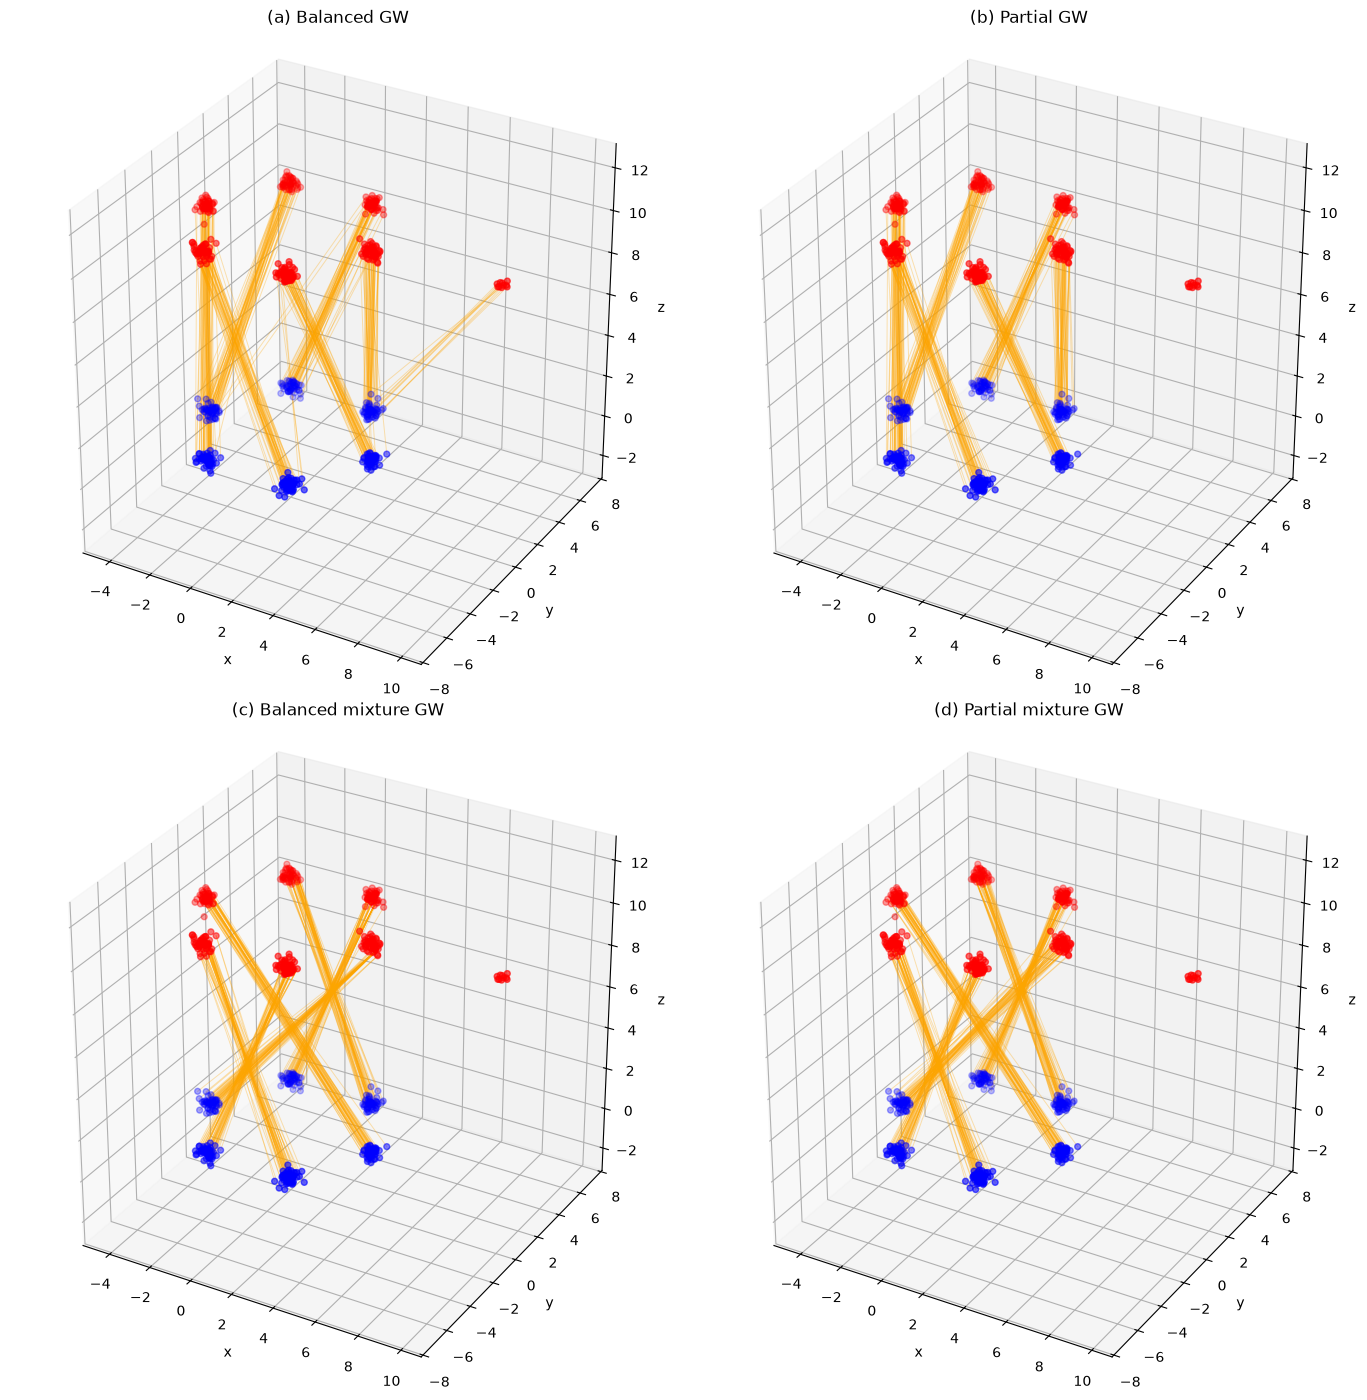

In [6]:
figure6 = make_figure6(figure67_data, figure67_solved)
figure6_path = OUTPUT_DIR / "figure6.pdf"
figure6.savefig(figure6_path, format="pdf", bbox_inches="tight")
write_figure_sidecar(
    METADATA_DIR / "figure6.json",
    figure=6,
    outputs=[figure6_path],
    panels=method_panels,
    inputs=common_inputs,
    seeds={
        "source_sampling": DEFAULT_SEED,
        "target_sampling": DEFAULT_SEED + 1,
        "noise_sampling": DEFAULT_SEED + 2,
        "fit": DEFAULT_SEED,
    },
    notes="All four methods use barycentric projections before nearest assignment.",
)
plt.show()


## Figure 7 — raw maps from the same MGW2 and pMGW2 solves


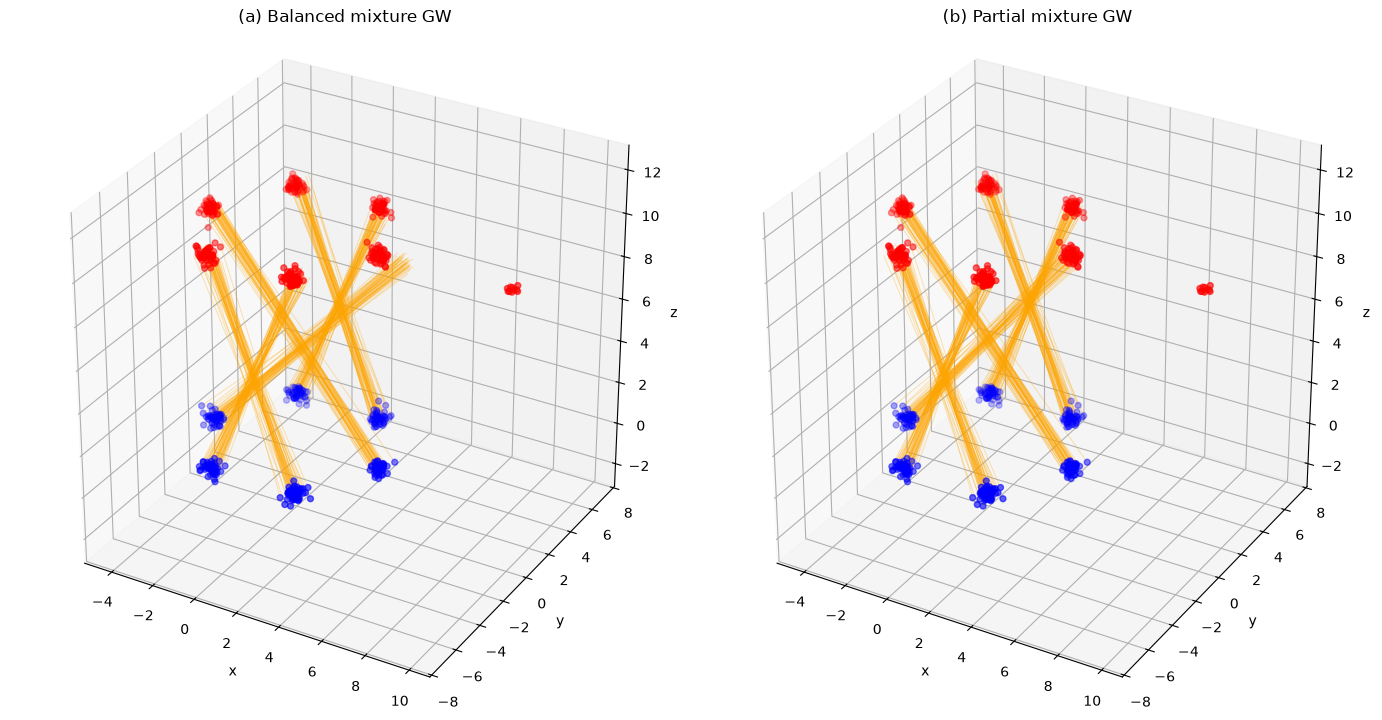

In [7]:
figure7 = make_figure7(figure67_data, figure67_solved)
figure7_path = OUTPUT_DIR / "figure7.pdf"
figure7.savefig(figure7_path, format="pdf", bbox_inches="tight")
mixture_panels = [
    panel for panel in method_panels if panel["method"] in {"MGW2", "pMGW2"}
]
write_figure_sidecar(
    METADATA_DIR / "figure7.json",
    figure=7,
    outputs=[figure7_path],
    panels=mixture_panels,
    inputs=common_inputs,
    seeds={
        "source_sampling": DEFAULT_SEED,
        "target_sampling": DEFAULT_SEED + 1,
        "noise_sampling": DEFAULT_SEED + 2,
        "fit": DEFAULT_SEED,
    },
    notes="solve_id values are identical to the MGW2/pMGW2 panels in Figure 6.",
)
plt.show()
